In [1]:
from process import create_datasets, get_BTTS_odds, get_fixtures
from utils import convert_btts_odds_to_probability, get_actual_results
from neural_network import NeuralNetwork
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [2]:
match_data = pd.read_csv("data/processed.csv")
odds_data = pd.read_csv("data/betting_odds.csv")

X_train, y_train, X_test, y_test = create_datasets(match_data, 6, 37)
 
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test)

C:\Users\marti\AppData\Local\Temp\ipykernel_6544\3100154472.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.from_numpy(y_train)


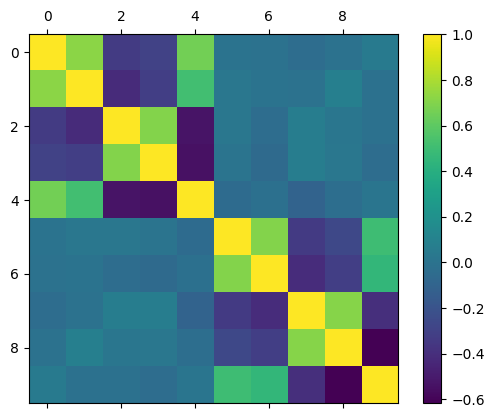

In [3]:
figure = plt.figure()
ax = figure.add_subplot()
cov_ax = ax.matshow(np.cov(X_train.T))
plt.colorbar(cov_ax)
plt.show()

In [5]:
final_fixtures = get_fixtures(match_data, 38)

home_teams = []
away_teams = []
btts_yes = []
btts_no = []

for home, away in final_fixtures:
    home_teams.append(home)
    away_teams.append(away)
    home_odds_df = odds_data[odds_data["homeTeam"] == home]
    match_row = home_odds_df[home_odds_df["awayTeam"] == away]
    btts_yes.append(match_row["BTTSY"].item())
    btts_no.append(match_row["BTTSN"].item())

final_fixtures_df = pd.DataFrame({"Home": home_teams, "Away": away_teams, "btts yes": btts_yes,
                                  "btts no": btts_no})
final_fixtures_df["btts_yes_prob"] = final_fixtures_df.apply(lambda row: convert_btts_odds_to_probability(row["btts yes"]), axis=1)
final_fixtures_df["btts_no_prob"] = final_fixtures_df.apply(lambda row: convert_btts_odds_to_probability(row["btts no"]), axis=1)
final_fixtures_df = final_fixtures_df.round(3)
final_fixtures_df.head(10)

,Home,Away,btts yes,btts no,btts_yes_prob,btts_no_prob
0,Bournemouth,Leicester,1.72,2.12,0.581,0.472
1,Fulham,Manchester City,1.65,2.24,0.606,0.446
2,Ipswich,West Ham,1.62,2.31,0.617,0.433
3,Liverpool,Crystal Palace,1.52,2.54,0.658,0.394
4,Manchester United,Aston Villa,1.60,2.34,0.625,0.427
5,Newcastle United,Everton,1.76,2.06,0.568,0.485
6,Nottingham Forest,Chelsea,1.60,2.34,0.625,0.427
7,Southampton,Arsenal,1.83,1.98,0.546,0.505
8,Tottenham,Brighton,1.48,2.68,0.676,0.373
9,Wolves,Brentford,1.48,2.68,0.676,0.373


## Neural Network

In [6]:
neural_net = NeuralNetwork(features=10, hidden_one=32, hidden_two=32)
neural_net.create()
neural_net.configure()
neural_net.train(30, X_train, y_train)
predicted_odds_nn = neural_net.predict(X_test)

final_fixtures_df["btts yes prob nn"] = [i[1].item() for i in predicted_odds_nn]

c:\Users\marti\OneDrive\Documents\Python\Football-Betting\.venv\Lib\site-packages\torch\nn\modules\module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


## Logistic Regression

In [7]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
predicted_odds_logreg = logreg.predict_proba(X_test)

final_fixtures_df["btts yes prob logreg"] = [i[1].item() for i in predicted_odds_logreg]

## XG Boost

In [ ]:
xgb_data_train = xgb.DMatrix(X_train, label=y_train)
xgb_data_test = xgb.DMatrix(X_test)

xgb_params = {"objective": "binary:logistic"}
trained = xgb.train(xgb_params, xgb_data_train, num_boost_round=10)
predicted_odds_xgb = trained.predict(xgb_data_test)

final_fixtures_df["btts yes prob xgb"] = predicted_odds_xgb

In [15]:
final_fixtures_df["btts yes prob ensemble"] = (final_fixtures_df["btts yes prob nn"] + final_fixtures_df["btts yes prob logreg"] +
                                               final_fixtures_df["btts yes prob xgb"])/3
final_fixtures_df = final_fixtures_df.round(3)
final_fixtures_df.head(10)

,Home,Away,btts yes,btts no,btts_yes_prob,btts_no_prob,btts yes prob nn,btts yes prob logreg,bbts yes prob xgb,btts yes prob xgb,btts yes prob ensemble
0,Bournemouth,Leicester,1.72,2.12,0.581,0.472,0.577,0.592,0.692,0.692,0.620
1,Fulham,Manchester City,1.65,2.24,0.606,0.446,0.516,0.438,0.339,0.339,0.431
2,Ipswich,West Ham,1.62,2.31,0.617,0.433,0.568,0.561,0.458,0.458,0.529
3,Liverpool,Crystal Palace,1.52,2.54,0.658,0.394,0.501,0.496,0.648,0.648,0.548
4,Manchester United,Aston Villa,1.60,2.34,0.625,0.427,0.603,0.558,0.780,0.780,0.647
5,Newcastle United,Everton,1.76,2.06,0.568,0.485,0.630,0.524,0.812,0.812,0.655
6,Nottingham Forest,Chelsea,1.60,2.34,0.625,0.427,0.535,0.566,0.725,0.725,0.609
7,Southampton,Arsenal,1.83,1.98,0.546,0.505,0.603,0.599,0.915,0.915,0.706
8,Tottenham,Brighton,1.48,2.68,0.676,0.373,0.546,0.650,0.674,0.674,0.623
9,Wolves,Brentford,1.48,2.68,0.676,0.373,0.626,0.701,0.670,0.670,0.666


In [10]:
get_actual_results(match_data, gameweek=38)

,home_team,home_score,away_score,away_team,btts
370,Bournemouth,2,0,Leicester,False
371,Fulham,0,2,Manchester City,False
372,Ipswich,1,3,West Ham,True
373,Liverpool,1,1,Crystal Palace,True
374,Manchester United,2,0,Aston Villa,False
375,Newcastle United,0,1,Everton,False
376,Nottingham Forest,0,1,Chelsea,False
377,Southampton,1,2,Arsenal,True
378,Tottenham,1,4,Brighton,True
379,Wolves,1,1,Brentford,True
